#### Loan Approval Prediction using Cross Validation


1.  The main objective of the project is to approve the loan of the particular customer or not based on its given information like 

(a.)    Income

(b.)    Education

(c.)    Marital Status

(d.)   Credit History

(e.)   Loan Amount

(f.)   Employment Status


2.  We need to build a good classification model for the above problem statement and evaluate it using Cross Validation


#### Step 1:    Import  all the necessary libraries


In [1]:
import  numpy               as  np
import  pandas              as  pd
import  matplotlib.pyplot   as  plt
import  seaborn             as  sns

from    sklearn.model_selection     import  train_test_split, GridSearchCV, StratifiedKFold
from    sklearn.preprocessing       import  StandardScaler
from    sklearn.linear_model        import  LogisticRegression
from    sklearn.metrics             import  accuracy_score, confusion_matrix, classification_report, f1_score, recall_score, precision_score, roc_curve, roc_auc_score

####    Step 2: Load the dataset

In [2]:
df = pd.read_csv("loan_prediction.csv")

In [3]:
df.head()

,ApplicantIncome,CoapplicantIncome,Credit_History,Dependents,Education,Gender,LoanAmount,Loan_Amount_Term,Loan_ID,Loan_Status,Married,Property_Area,Self_Employed
0,5849,0.0,1.0,0,Graduate,Male,NaN,360.0,LP001002,Y,No,Urban,No
1,4583,1508.0,1.0,1,Graduate,Male,128.0,360.0,LP001003,N,Yes,Rural,No
2,3000,0.0,1.0,0,Graduate,Male,66.0,360.0,LP001005,Y,Yes,Urban,Yes
3,2583,2358.0,1.0,0,Not Graduate,Male,120.0,360.0,LP001006,Y,Yes,Urban,No
4,6000,0.0,1.0,0,Graduate,Male,141.0,360.0,LP001008,Y,No,Urban,No


#### OBSERVATIONS:

1.  The above dataset explains about the details of all the customers who are availing for a loan.

2.  The target feature is the "Loan_Status" that depicts about whether the customer will get a loan or not.

        (a.)    If Loan_Status = "Y" ============>   Customer can avail for a loan

        (b.)    If Loan_Status = "N" ============>   Customer cannot avail for a loan.

In [4]:
df['Loan_Status'].value_counts()

Loan_Status
Y    422
N    192
Name: count, dtype: int64

#### Step 3: Perform the Data Exploration

In [5]:
#### get the first five rows of the dataset

df.head()

,ApplicantIncome,CoapplicantIncome,Credit_History,Dependents,Education,Gender,LoanAmount,Loan_Amount_Term,Loan_ID,Loan_Status,Married,Property_Area,Self_Employed
0,5849,0.0,1.0,0,Graduate,Male,NaN,360.0,LP001002,Y,No,Urban,No
1,4583,1508.0,1.0,1,Graduate,Male,128.0,360.0,LP001003,N,Yes,Rural,No
2,3000,0.0,1.0,0,Graduate,Male,66.0,360.0,LP001005,Y,Yes,Urban,Yes
3,2583,2358.0,1.0,0,Not Graduate,Male,120.0,360.0,LP001006,Y,Yes,Urban,No
4,6000,0.0,1.0,0,Graduate,Male,141.0,360.0,LP001008,Y,No,Urban,No


In [6]:
#### get the last five rows of the dataset

df.tail()

,ApplicantIncome,CoapplicantIncome,Credit_History,Dependents,Education,Gender,LoanAmount,Loan_Amount_Term,Loan_ID,Loan_Status,Married,Property_Area,Self_Employed
976,4009,1777.0,1.0,3+,Not Graduate,Male,113.0,360.0,LP002971,NaN,Yes,Urban,Yes
977,4158,709.0,1.0,0,Graduate,Male,115.0,360.0,LP002975,NaN,Yes,Urban,No
978,3250,1993.0,NaN,0,Graduate,Male,126.0,360.0,LP002980,NaN,No,Semiurban,No
979,5000,2393.0,1.0,0,Graduate,Male,158.0,360.0,LP002986,NaN,Yes,Rural,No
980,9200,0.0,1.0,0,Graduate,Male,98.0,180.0,LP002989,NaN,No,Rural,Yes


In [7]:
#### get the length of the dataset 

print("Length of the dataset is:", len(df))

Length of the dataset is: 981


In [8]:
#### get the shape of the dataset

print("Shape of the dataset is:", df.shape)

Shape of the dataset is: (981, 13)


In [9]:
#### get the columns used in the dataset

df.columns

Index(['ApplicantIncome', 'CoapplicantIncome', 'Credit_History', 'Dependents',
       'Education', 'Gender', 'LoanAmount', 'Loan_Amount_Term', 'Loan_ID',
       'Loan_Status', 'Married', 'Property_Area', 'Self_Employed'],
      dtype='object')

In [10]:
#### get the information about the columns used in the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 981 entries, 0 to 980
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ApplicantIncome    981 non-null    int64  
 1   CoapplicantIncome  981 non-null    float64
 2   Credit_History     902 non-null    float64
 3   Dependents         956 non-null    object 
 4   Education          981 non-null    object 
 5   Gender             957 non-null    object 
 6   LoanAmount         954 non-null    float64
 7   Loan_Amount_Term   961 non-null    float64
 8   Loan_ID            981 non-null    object 
 9   Loan_Status        614 non-null    object 
 10  Married            978 non-null    object 
 11  Property_Area      981 non-null    object 
 12  Self_Employed      926 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 99.8+ KB


In [11]:
#### get the descriptive statistical summary about the numerical columns used in the dataset

df.describe()

,ApplicantIncome,CoapplicantIncome,Credit_History,LoanAmount,Loan_Amount_Term
count,981.000000,981.000000,902.000000,954.000000,961.000000
mean,5179.795107,1601.916330,0.835920,142.511530,342.201873
std,5695.104533,2718.772806,0.370553,77.421743,65.100602
min,0.000000,0.000000,0.000000,9.000000,6.000000
25%,2875.000000,0.000000,1.000000,100.000000,360.000000
50%,3800.000000,1110.000000,1.000000,126.000000,360.000000
75%,5516.000000,2365.000000,1.000000,162.000000,360.000000
max,81000.000000,41667.000000,1.000000,700.000000,480.000000


#### OBSERATIONS:

1.  The above table explains about the descriptive statistical summary for each numerical column in the dataset.

In [12]:
#### get the descriptive statistical summary about the categorical columns used in the dataset 

df.describe(include='object')

,Dependents,Education,Gender,Loan_ID,Loan_Status,Married,Property_Area,Self_Employed
count,956,981,957,981,614,978,981,926
unique,4,2,2,981,2,2,3,2
top,0,Graduate,Male,LP002989,Y,Yes,Semiurban,No
freq,545,763,775,1,422,631,349,807


#### OBSERATIONS:

1.  The above table explains about the descriptive statistical summary for each categorical column in the dataset.

#### Step 4: Perform Data Cleaning and Feature Engineering

In [13]:
#### Check for the missing values in the dataset

df.isnull().sum()

ApplicantIncome        0
CoapplicantIncome      0
Credit_History        79
Dependents            25
Education              0
Gender                24
LoanAmount            27
Loan_Amount_Term      20
Loan_ID                0
Loan_Status          367
Married                3
Property_Area          0
Self_Employed         55
dtype: int64

#### OBSERVATIONS:

1.  There are some missing values in some of the columns in the dataset.

In [14]:
df.head()

,ApplicantIncome,CoapplicantIncome,Credit_History,Dependents,Education,Gender,LoanAmount,Loan_Amount_Term,Loan_ID,Loan_Status,Married,Property_Area,Self_Employed
0,5849,0.0,1.0,0,Graduate,Male,NaN,360.0,LP001002,Y,No,Urban,No
1,4583,1508.0,1.0,1,Graduate,Male,128.0,360.0,LP001003,N,Yes,Rural,No
2,3000,0.0,1.0,0,Graduate,Male,66.0,360.0,LP001005,Y,Yes,Urban,Yes
3,2583,2358.0,1.0,0,Not Graduate,Male,120.0,360.0,LP001006,Y,Yes,Urban,No
4,6000,0.0,1.0,0,Graduate,Male,141.0,360.0,LP001008,Y,No,Urban,No


In [15]:
#### Resolve the NULL Values for all the nuemrical columns in the dataset

x = ["Credit_History","LoanAmount","Loan_Amount_Term"]


for i in x:
    df[i]   =   df[i].fillna(df[i].mean())

In [16]:
#### Again check for the missing values in the dataset

df.isnull().sum()

ApplicantIncome        0
CoapplicantIncome      0
Credit_History         0
Dependents            25
Education              0
Gender                24
LoanAmount             0
Loan_Amount_Term       0
Loan_ID                0
Loan_Status          367
Married                3
Property_Area          0
Self_Employed         55
dtype: int64

#### OBSERVATIONS:

1.  All the numerical columns that has NULL values earlier were filled with the mean values of that respective column.

In [17]:
df.head()

,ApplicantIncome,CoapplicantIncome,Credit_History,Dependents,Education,Gender,LoanAmount,Loan_Amount_Term,Loan_ID,Loan_Status,Married,Property_Area,Self_Employed
0,5849,0.0,1.0,0,Graduate,Male,142.51153,360.0,LP001002,Y,No,Urban,No
1,4583,1508.0,1.0,1,Graduate,Male,128.00000,360.0,LP001003,N,Yes,Rural,No
2,3000,0.0,1.0,0,Graduate,Male,66.00000,360.0,LP001005,Y,Yes,Urban,Yes
3,2583,2358.0,1.0,0,Not Graduate,Male,120.00000,360.0,LP001006,Y,Yes,Urban,No
4,6000,0.0,1.0,0,Graduate,Male,141.00000,360.0,LP001008,Y,No,Urban,No


In [18]:
df.isnull().sum()

ApplicantIncome        0
CoapplicantIncome      0
Credit_History         0
Dependents            25
Education              0
Gender                24
LoanAmount             0
Loan_Amount_Term       0
Loan_ID                0
Loan_Status          367
Married                3
Property_Area          0
Self_Employed         55
dtype: int64

In [19]:
#### Handle all the categorical columns having NULL Values in the dataset

df[["Dependents","Gender","Loan_Status","Married","Self_Employed"]]

,Dependents,Gender,Loan_Status,Married,Self_Employed
0,0,Male,Y,No,No
1,1,Male,N,Yes,No
2,0,Male,Y,Yes,Yes
3,0,Male,Y,Yes,No
4,0,Male,Y,No,No
...,...,...,...,...,...
976,3+,Male,NaN,Yes,Yes
977,0,Male,NaN,Yes,No
978,0,Male,NaN,No,No
979,0,Male,NaN,Yes,No


In [20]:
x = ["Dependents","Gender","Loan_Status","Married","Self_Employed"]

#### Replace all the NULL Values in the catgeorical columns with the model value of it

for i in x:
    df[i] = df[i].fillna(df[i].mode()[0])

In [21]:
#### Again check for any NULL Values in the dataset

df.isnull().sum()

ApplicantIncome      0
CoapplicantIncome    0
Credit_History       0
Dependents           0
Education            0
Gender               0
LoanAmount           0
Loan_Amount_Term     0
Loan_ID              0
Loan_Status          0
Married              0
Property_Area        0
Self_Employed        0
dtype: int64

#### OBSERVATIONS:

1.  There are no NULL Values in the dataset.

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 981 entries, 0 to 980
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ApplicantIncome    981 non-null    int64  
 1   CoapplicantIncome  981 non-null    float64
 2   Credit_History     981 non-null    float64
 3   Dependents         981 non-null    object 
 4   Education          981 non-null    object 
 5   Gender             981 non-null    object 
 6   LoanAmount         981 non-null    float64
 7   Loan_Amount_Term   981 non-null    float64
 8   Loan_ID            981 non-null    object 
 9   Loan_Status        981 non-null    object 
 10  Married            981 non-null    object 
 11  Property_Area      981 non-null    object 
 12  Self_Employed      981 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 99.8+ KB


In [23]:
df.head()

,ApplicantIncome,CoapplicantIncome,Credit_History,Dependents,Education,Gender,LoanAmount,Loan_Amount_Term,Loan_ID,Loan_Status,Married,Property_Area,Self_Employed
0,5849,0.0,1.0,0,Graduate,Male,142.51153,360.0,LP001002,Y,No,Urban,No
1,4583,1508.0,1.0,1,Graduate,Male,128.00000,360.0,LP001003,N,Yes,Rural,No
2,3000,0.0,1.0,0,Graduate,Male,66.00000,360.0,LP001005,Y,Yes,Urban,Yes
3,2583,2358.0,1.0,0,Not Graduate,Male,120.00000,360.0,LP001006,Y,Yes,Urban,No
4,6000,0.0,1.0,0,Graduate,Male,141.00000,360.0,LP001008,Y,No,Urban,No


In [24]:
#### Resolve for all the categorical values in the dataset

x = ["Education","Gender","Loan_Status","Married","Property_Area","Self_Employed"]

from sklearn.preprocessing import LabelEncoder

label = LabelEncoder()

for i in x:
    df[i]   =   label.fit_transform(df[i])

In [25]:
df.isnull().sum()

ApplicantIncome      0
CoapplicantIncome    0
Credit_History       0
Dependents           0
Education            0
Gender               0
LoanAmount           0
Loan_Amount_Term     0
Loan_ID              0
Loan_Status          0
Married              0
Property_Area        0
Self_Employed        0
dtype: int64

#### OBSERVATIONS:

1.  There are no NULL Values in the dataset.

In [26]:
df['Dependents'].value_counts()

Dependents
0     570
1     160
2     160
3+     91
Name: count, dtype: int64

In [27]:
#### Replace 3+ to 3

df['Dependents'] = df['Dependents'].replace('3+','3')

In [28]:
df['Dependents'].value_counts()

Dependents
0    570
1    160
2    160
3     91
Name: count, dtype: int64

In [29]:
df['Dependents'] = df['Dependents'].astype('int')

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 981 entries, 0 to 980
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ApplicantIncome    981 non-null    int64  
 1   CoapplicantIncome  981 non-null    float64
 2   Credit_History     981 non-null    float64
 3   Dependents         981 non-null    int64  
 4   Education          981 non-null    int64  
 5   Gender             981 non-null    int64  
 6   LoanAmount         981 non-null    float64
 7   Loan_Amount_Term   981 non-null    float64
 8   Loan_ID            981 non-null    object 
 9   Loan_Status        981 non-null    int64  
 10  Married            981 non-null    int64  
 11  Property_Area      981 non-null    int64  
 12  Self_Employed      981 non-null    int64  
dtypes: float64(4), int64(8), object(1)
memory usage: 99.8+ KB


#### OBSERVATIONS:

1.  All the categorical columns have been converted into the integer columns in the dataset.

In [31]:
df.head()

,ApplicantIncome,CoapplicantIncome,Credit_History,Dependents,Education,Gender,LoanAmount,Loan_Amount_Term,Loan_ID,Loan_Status,Married,Property_Area,Self_Employed
0,5849,0.0,1.0,0,0,1,142.51153,360.0,LP001002,1,0,2,0
1,4583,1508.0,1.0,1,0,1,128.00000,360.0,LP001003,0,1,0,0
2,3000,0.0,1.0,0,0,1,66.00000,360.0,LP001005,1,1,2,1
3,2583,2358.0,1.0,0,1,1,120.00000,360.0,LP001006,1,1,2,0
4,6000,0.0,1.0,0,0,1,141.00000,360.0,LP001008,1,0,2,0


In [32]:
df['Loan_Status'].value_counts()

Loan_Status
1    789
0    192
Name: count, dtype: int64

In [33]:
#### Check for the duplicate records in the dataset

df[df.duplicated()]

,ApplicantIncome,CoapplicantIncome,Credit_History,Dependents,Education,Gender,LoanAmount,Loan_Amount_Term,Loan_ID,Loan_Status,Married,Property_Area,Self_Employed


#### OBSERVATIONS:

1.  There are no duplicate records in the dataset.

In [34]:
df['Education'].value_counts()

Education
0    763
1    218
Name: count, dtype: int64

In [35]:
df['Property_Area'].value_counts()

Property_Area
1    349
2    342
0    290
Name: count, dtype: int64

#### OBSERVATIONS:

1.  All the numerical values in the categorical columns have been properly assigned.

In [36]:
#### Remove the unnecessary column "Loan_ID" from the dataset

df.drop(columns="Loan_ID",axis=1,inplace=True)

In [37]:
df.head()

,ApplicantIncome,CoapplicantIncome,Credit_History,Dependents,Education,Gender,LoanAmount,Loan_Amount_Term,Loan_Status,Married,Property_Area,Self_Employed
0,5849,0.0,1.0,0,0,1,142.51153,360.0,1,0,2,0
1,4583,1508.0,1.0,1,0,1,128.00000,360.0,0,1,0,0
2,3000,0.0,1.0,0,0,1,66.00000,360.0,1,1,2,1
3,2583,2358.0,1.0,0,1,1,120.00000,360.0,1,1,2,0
4,6000,0.0,1.0,0,0,1,141.00000,360.0,1,0,2,0


#### OBSERVATIONS:

1.  The "Load_ID" column has been removed from the dataset.

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 981 entries, 0 to 980
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ApplicantIncome    981 non-null    int64  
 1   CoapplicantIncome  981 non-null    float64
 2   Credit_History     981 non-null    float64
 3   Dependents         981 non-null    int64  
 4   Education          981 non-null    int64  
 5   Gender             981 non-null    int64  
 6   LoanAmount         981 non-null    float64
 7   Loan_Amount_Term   981 non-null    float64
 8   Loan_Status        981 non-null    int64  
 9   Married            981 non-null    int64  
 10  Property_Area      981 non-null    int64  
 11  Self_Employed      981 non-null    int64  
dtypes: float64(4), int64(8)
memory usage: 92.1 KB


#### OBSERVATIONS:

1.  The revised dataset columns are al integer or floating in nature.

2.  All the categorical columns have been converted from the catgeorical values to integer or floating values.

In [39]:
#### Again check for the NULL records in the revised dataset

df.isnull().sum()

ApplicantIncome      0
CoapplicantIncome    0
Credit_History       0
Dependents           0
Education            0
Gender               0
LoanAmount           0
Loan_Amount_Term     0
Loan_Status          0
Married              0
Property_Area        0
Self_Employed        0
dtype: int64

#### OBSERVATIONS:

1.  The revised dataset has no NULL records in the dataset.

In [40]:
#### Again check for the duplicate records in the revised dataset

df[df.duplicated()]

,ApplicantIncome,CoapplicantIncome,Credit_History,Dependents,Education,Gender,LoanAmount,Loan_Amount_Term,Loan_Status,Married,Property_Area,Self_Employed
809,5833,0.0,1.0,0,0,1,116.0,360.0,1,0,2,1


#### OBSERVATIONS:

1.  The revised dataset has one duplicate record in it. So remove the dupliacte record from the dataset.

In [41]:
df.drop_duplicates(inplace=True)

In [42]:
#### Again check for the duplicate records in the revised dataset

df[df.duplicated()]

,ApplicantIncome,CoapplicantIncome,Credit_History,Dependents,Education,Gender,LoanAmount,Loan_Amount_Term,Loan_Status,Married,Property_Area,Self_Employed


#### OBSERVATIONS:

1.  There are no duplicate records in the dataset.

In [43]:
#### again get the length of the revised dataset 

print("Length of the dataset is:", len(df))

Length of the dataset is: 980


In [44]:
#### again get the shape of the revised dataset 

print("Shape of the dataset is:", df.shape)

Shape of the dataset is: (980, 12)


#### OBSERVATIONS:

1.  There was one duplicate record in the dataset. That record was removed. So the length of the dataset got reduced from 981 to 980.


2.  "LoanID" was the unnecessary column in the dataset and it was removed from the dataset. So the number of columns got reduced from 13 to 12.

In [45]:
df.head()

,ApplicantIncome,CoapplicantIncome,Credit_History,Dependents,Education,Gender,LoanAmount,Loan_Amount_Term,Loan_Status,Married,Property_Area,Self_Employed
0,5849,0.0,1.0,0,0,1,142.51153,360.0,1,0,2,0
1,4583,1508.0,1.0,1,0,1,128.00000,360.0,0,1,0,0
2,3000,0.0,1.0,0,0,1,66.00000,360.0,1,1,2,1
3,2583,2358.0,1.0,0,1,1,120.00000,360.0,1,1,2,0
4,6000,0.0,1.0,0,0,1,141.00000,360.0,1,0,2,0


#### Step 5: Perform EDA

In [46]:
#### Get the correlation for all the columns in the dataset

df.corr()

,ApplicantIncome,CoapplicantIncome,Credit_History,Dependents,Education,Gender,LoanAmount,Loan_Amount_Term,Loan_Status,Married,Property_Area,Self_Employed
ApplicantIncome,1.000000,-0.114199,0.022707,0.122258,-0.138867,0.060395,0.547267,-0.023085,-0.023138,0.052333,0.005379,0.113210
CoapplicantIncome,-0.114199,1.000000,-0.022803,0.002776,-0.060721,0.082739,0.178283,-0.043549,-0.049802,0.060861,-0.024232,-0.017309
Credit_History,0.022707,-0.022803,1.000000,-0.044609,-0.063175,0.021393,-0.007369,-0.019417,0.380626,0.022625,0.021752,0.034460
Dependents,0.122258,0.002776,-0.044609,1.000000,0.084524,0.139666,0.149020,-0.082333,0.018780,0.343681,0.019558,0.028400
Education,-0.138867,-0.060721,-0.063175,0.084524,1.000000,0.040921,-0.162438,-0.023855,-0.057427,0.025501,-0.050083,-0.009416
Gender,0.060395,0.082739,0.021393,0.139666,0.040921,1.000000,0.096685,-0.069771,0.008878,0.328014,-0.021394,0.023498
LoanAmount,0.547267,0.178283,-0.007369,0.149020,-0.162438,0.096685,1.000000,0.054930,-0.052912,0.156414,-0.035261,0.108304
Loan_Amount_Term,-0.023085,-0.043549,-0.019417,-0.082333,-0.023855,-0.069771,0.054930,1.000000,-0.013963,-0.047840,-0.042575,-0.031986
Loan_Status,-0.023138,-0.049802,0.380626,0.018780,-0.057427,0.008878,-0.052912,-0.013963,1.000000,0.060315,0.032081,-0.022764
Married,0.052333,0.060861,0.022625,0.343681,0.025501,0.328014,0.156414,-0.047840,0.060315,1.000000,0.008016,0.017459


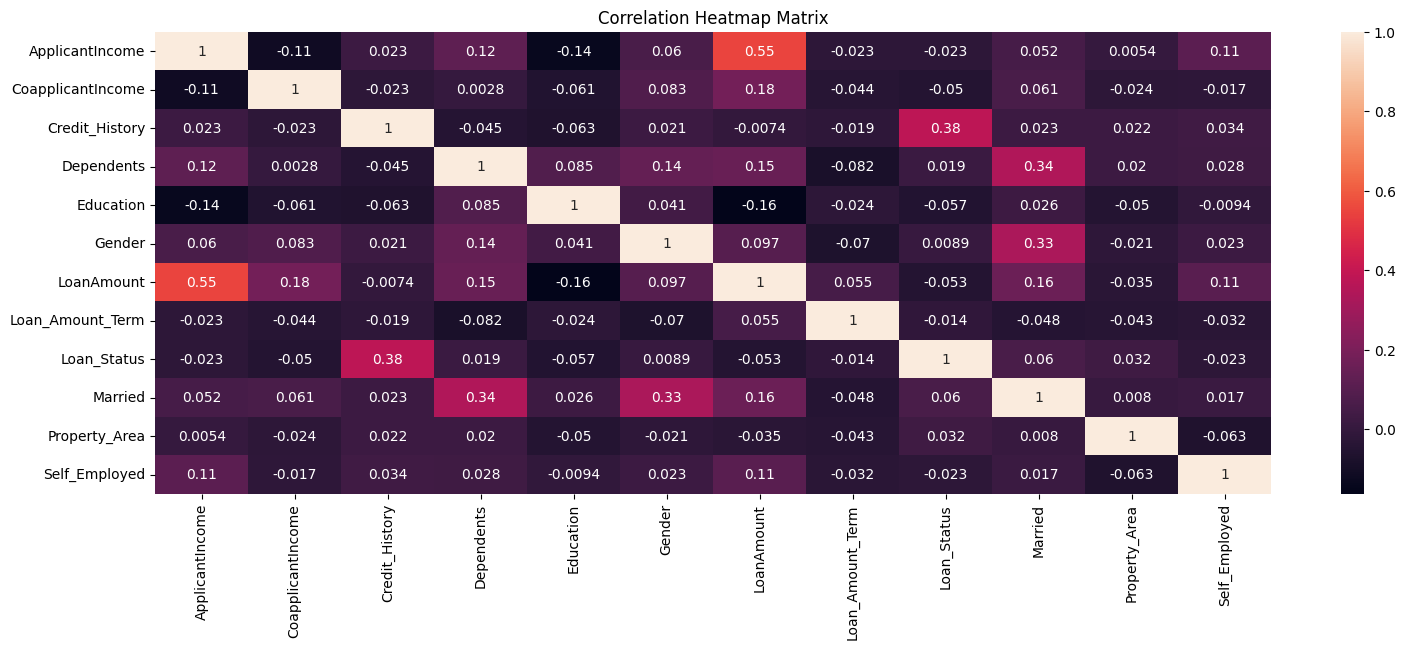

In [47]:
#### Get the graphical representation for the correlation for all the columns in the dataset


plt.figure(figsize=(18,6))
sns.heatmap(df.corr(),annot=True)
plt.title("Correlation Heatmap Matrix")
plt.show()

#### OBSERVATIONS:

1.  The above matrix depicts about the graphical representation for each column with every column used in the dataset.

#### Step 6:    Divide the dataset into independent and dependent features

In [48]:
#### independent features

X = df.drop(columns='Loan_Status',axis=1)

print(X)

     ApplicantIncome  CoapplicantIncome  Credit_History  Dependents  \
0               5849                0.0         1.00000           0   
1               4583             1508.0         1.00000           1   
2               3000                0.0         1.00000           0   
3               2583             2358.0         1.00000           0   
4               6000                0.0         1.00000           0   
..               ...                ...             ...         ...   
976             4009             1777.0         1.00000           3   
977             4158              709.0         1.00000           0   
978             3250             1993.0         0.83592           0   
979             5000             2393.0         1.00000           0   
980             9200                0.0         1.00000           0   

     Education  Gender  LoanAmount  Loan_Amount_Term  Married  Property_Area  \
0            0       1   142.51153             360.0        0      

In [49]:
#### dependent features

Y = df['Loan_Status']

print(Y)

0      1
1      0
2      1
3      1
4      1
      ..
976    1
977    1
978    1
979    1
980    1
Name: Loan_Status, Length: 980, dtype: int64


#### Step 7: Divide the independent and dependent features into training and testing data

In [50]:
from sklearn.model_selection    import  train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2, random_state=42,stratify=Y)

In [51]:
X_train

,ApplicantIncome,CoapplicantIncome,Credit_History,Dependents,Education,Gender,LoanAmount,Loan_Amount_Term,Married,Property_Area,Self_Employed
884,1635,2444.0,1.0,3,1,0,99.00000,360.0,1,2,0
936,3400,0.0,1.0,3,0,1,80.00000,120.0,1,2,0
573,6125,1625.0,1.0,2,1,1,187.00000,480.0,1,1,0
322,3601,1590.0,1.0,2,1,1,142.51153,360.0,1,0,0
547,2526,1783.0,1.0,0,0,1,145.00000,360.0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
761,8703,0.0,0.0,0,1,1,199.00000,360.0,0,0,1
484,8333,0.0,1.0,2,0,1,246.00000,360.0,1,1,0
344,2583,2330.0,1.0,2,0,1,125.00000,360.0,1,0,0
899,8750,0.0,1.0,1,0,1,297.00000,360.0,1,2,0


In [52]:
X_test

,ApplicantIncome,CoapplicantIncome,Credit_History,Dependents,Education,Gender,LoanAmount,Loan_Amount_Term,Married,Property_Area,Self_Employed
43,3941,2336.0,1.0,0,0,1,134.0,360.0,1,1,0
930,4283,0.0,1.0,0,0,0,120.0,360.0,1,0,0
414,2149,3237.0,0.0,0,1,0,178.0,360.0,1,1,0
227,6250,1695.0,1.0,2,0,1,210.0,360.0,1,1,0
194,4191,0.0,1.0,0,0,1,120.0,360.0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
403,1963,0.0,1.0,0,1,0,53.0,360.0,0,1,0
154,3254,0.0,1.0,0,0,1,50.0,360.0,0,2,0
629,5667,0.0,1.0,1,0,1,131.0,360.0,0,2,0
351,8750,4167.0,1.0,0,0,1,308.0,360.0,0,0,0


In [53]:
print("Shape of the input training data is:", X_train.shape)
print("Shape of the input testing  data is:", X_test.shape)

Shape of the input training data is: (784, 11)
Shape of the input testing  data is: (196, 11)


In [54]:
Y_train

884    1
936    1
573    0
322    1
547    1
      ..
761    1
484    1
344    1
899    1
492    1
Name: Loan_Status, Length: 784, dtype: int64

In [55]:
Y_test

43     1
930    1
414    0
227    1
194    1
      ..
403    1
154    1
629    1
351    0
179    0
Name: Loan_Status, Length: 196, dtype: int64

In [56]:
Y_test.value_counts()

Loan_Status
1    158
0     38
Name: count, dtype: int64

In [57]:
print("Shape of the output training data is:", Y_train.shape)
print("Shape of the output testing  data is:", Y_test.shape)

Shape of the output training data is: (784,)
Shape of the output testing  data is: (196,)


#### OBSERVATIONS:

1.  Out of 980 total records in the dataset,

    (a.)    Training records = 784

    (b.)    Testing  records = 196

#### Step 8: Perform Hyper Parameter Tuning using GridSearchCV

In [58]:
#### define the pipeline

from    sklearn.pipeline    import  Pipeline

#### create an object for Pipeline

pipeline  =  Pipeline([
    ("sc"       ,       StandardScaler())               ,
    ("log"      ,       LogisticRegression(max_iter=1000))
])

In [59]:
#### define the param grid

param_grid = {
    "log__C"        :   [0.01,  0.1,    1,  10, 100]            ,
    "log__penalty"  :   ["l2"]                                  ,
    "log__solver"   :   ["lbfgs"    ,   "liblinear"]
}

####    OBSERVATIONS:

1.  All the parameters inside the param grid re accessible using log

2.  C ================>  Regularization Parameter

    (a.)    Lower the value of C ============>   Stronger is the regularization

    (b.)    Higher the value of C ===========>   Weaker is the regularization

3.  penalty ===========>  Type of regularization

    (a.)    l1 ============================>   performs the feature selection  

    (b.)    l2 ============================>   Reduces the overfitting


4.  solver ===========>  Type of optimization algorithm used to solve the problem

In [60]:
#### perform the Startified K Fold Cross Validation

cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

In [61]:
#### define the object for GridSearchCV

grid = GridSearchCV(
    pipeline                            ,
    param_grid = param_grid             ,
    cv         =    cv                  ,
    scoring    =  'accuracy'            ,
    n_jobs     =     -1
)

In [62]:
#### using the object of GridSearchCV, train the model

grid.fit(X_train, Y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('sc', StandardScaler()),
                                       ('log',
                                        LogisticRegression(max_iter=1000))]),
             n_jobs=-1,
             param_grid={'log__C': [0.01, 0.1, 1, 10, 100],
                         'log__penalty': ['l2'],
                         'log__solver': ['lbfgs', 'liblinear']},
             scoring='accuracy')

In [63]:
#### Obtain the best parameters and the estimator for the model

best_parameter = grid.best_params_

print("Best Parameter for the model is:", best_parameter)


best_estimator = grid.best_estimator_

print("Best Estimator for the model is:", best_estimator)

Best Parameter for the model is: {'log__C': 0.1, 'log__penalty': 'l2', 'log__solver': 'lbfgs'}
Best Estimator for the model is: Pipeline(steps=[('sc', StandardScaler()),
                ('log', LogisticRegression(C=0.1, max_iter=1000))])


In [64]:
#### Predict the model

Y_pred_grid = best_estimator.predict(X_test)

In [65]:
Y_pred_grid

array([1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0])

In [66]:
#### Evaluate the Classification Metrics

from   sklearn.metrics   import  accuracy_score, confusion_matrix, classification_report, precision_score, recall_score

print("===============================Accuracy score=======================================================")

acgrid = accuracy_score(Y_test, Y_pred_grid)*100.0

print("Accuracy score of the model is:", acgrid)



print("===============================Confusion matrix=======================================================")

cmgrid = confusion_matrix(Y_test, Y_pred_grid)

print("Confusion matrix of the model is:", cmgrid)



print("===============================Classification report=======================================================")

crgrid = classification_report(Y_test, Y_pred_grid)

print("Classification report of the model is:", crgrid)


print("===============================Precision Score=======================================================")

prgrid = precision_score(Y_test, Y_pred_grid)

print("Precision score of the model is:", prgrid)


print("===============================Recall Score=======================================================")

regrid = recall_score(Y_test, Y_pred_grid)

print("Recall score of the model is:", regrid)


print("===============================F1 Score=======================================================")

f1grid = f1_score(Y_test, Y_pred_grid)

print("F1 score of the model is:", f1grid)

===============================Accuracy score=======================================================
Accuracy score of the model is: 83.6734693877551
===============================Confusion matrix=======================================================
Confusion matrix of the model is: [[ 11  27]
 [  5 153]]
===============================Classification report=======================================================
Classification report of the model is:               precision    recall  f1-score   support

           0       0.69      0.29      0.41        38
           1       0.85      0.97      0.91       158

    accuracy                           0.84       196
   macro avg       0.77      0.63      0.66       196
weighted avg       0.82      0.84      0.81       196

===============================Precision Score=======================================================
Precision score of the model is: 0.85
===============================Recall Score=================================

#### OBSERVATIONS:

1.  The accuracy of the Logistic Regression Model using Loan_Prediction dataset is 83.67 suing Hyper Parameter Tuning with GridSearchCV. So the model is working fine.

#### roc_curve

    (a.)    roc_curve is a metrics that is used to evaluate the performance of the classification algorithm.

    (b.)    It is used to deal with the binary values

    (c.)    It depicts about full ROC curve data points

    (d.)    It explains the relationship between the False Positive Rate and the True Positive Rate


![image.png](attachment:image.png)

In [67]:
#### Perform the probabilities for all the class labels

Y_pred_proba = best_estimator.predict_proba(X_test)[:,1]

In [68]:
Y_pred_proba

array([0.8757073 , 0.8897122 , 0.46381567, 0.89435893, 0.8472535 ,
       0.87918162, 0.8972655 , 0.88940663, 0.82764209, 0.48735616,
       0.80783084, 0.51061008, 0.48960944, 0.83098278, 0.86723137,
       0.88087169, 0.92405278, 0.90206493, 0.88860871, 0.6390471 ,
       0.8423225 , 0.86774143, 0.88008873, 0.90288429, 0.87838485,
       0.86071115, 0.79728786, 0.86135222, 0.85509734, 0.71027225,
       0.86301325, 0.84920246, 0.86927993, 0.4550753 , 0.90762488,
       0.87593997, 0.90311093, 0.88525148, 0.74821733, 0.82549089,
       0.53050816, 0.413735  , 0.87206189, 0.85475773, 0.82564808,
       0.80745502, 0.8921133 , 0.88867795, 0.70138133, 0.88885192,
       0.86794305, 0.88407305, 0.88296452, 0.86366573, 0.85720028,
       0.45380797, 0.8772024 , 0.73318219, 0.88406964, 0.85528814,
       0.82619676, 0.80460746, 0.88321339, 0.80545653, 0.83773626,
       0.88053089, 0.72186796, 0.8471295 , 0.45217476, 0.33944431,
       0.42212281, 0.76518081, 0.89002644, 0.90203186, 0.88128

In [69]:
#### perform the ROC AUC Score

rocaucscore = roc_auc_score(Y_test, Y_pred_proba)

print("ROC AUC Score of the model is:", rocaucscore)

ROC AUC Score of the model is: 0.7471685542971352


#### OBSERVATIONS:

1.  The ROC AUC Score is a single numerical vaue that explains how well the model seperates between the datas of Class 0 and Class 1 

2.  It easily seperates the datas of two different categories.

3.  This model with the ROC AUC Score of 0.7471 explains that the model has 74.71 % of the ability to determine correctly whether the loan can be approved or not for the customer.


False Positive Rate is: [0.         0.         0.         0.02631579 0.02631579 0.05263158
 0.05263158 0.07894737 0.07894737 0.10526316 0.10526316 0.13157895
 0.13157895 0.15789474 0.15789474 0.18421053 0.18421053 0.21052632
 0.21052632 0.23684211 0.23684211 0.26315789 0.26315789 0.28947368
 0.28947368 0.31578947 0.31578947 0.34210526 0.34210526 0.36842105
 0.36842105 0.39473684 0.39473684 0.42105263 0.42105263 0.44736842
 0.44736842 0.47368421 0.47368421 0.63157895 0.63157895 0.68421053
 0.68421053 0.84210526 0.84210526 0.86842105 0.86842105 0.97368421
 0.97368421 1.        ]
True Positive Rate is: [0.         0.00632911 0.01265823 0.01265823 0.03164557 0.03164557
 0.13291139 0.13291139 0.15822785 0.15822785 0.3164557  0.3164557
 0.34810127 0.34810127 0.37974684 0.37974684 0.39240506 0.39240506
 0.40506329 0.40506329 0.49367089 0.49367089 0.63291139 0.63291139
 0.65189873 0.65189873 0.67721519 0.67721519 0.74050633 0.74050633
 0.85443038 0.85443038 0.86075949 0.86075949 0.92405063 0.9

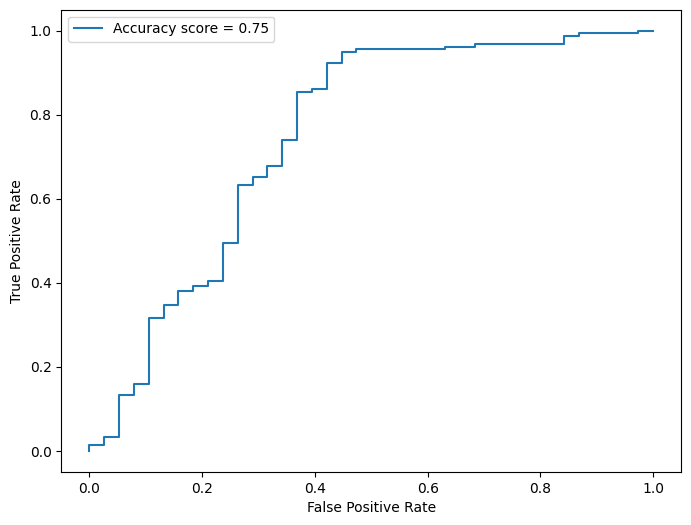

In [70]:
#### perform the ROC Curve

fpr, tpr, thresholds = roc_curve(Y_test, Y_pred_proba)

print("False Positive Rate is:", fpr)

print("True Positive Rate is:", tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,label=f"Accuracy score = {rocaucscore:.2f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

#### OBSERVATIONS:

1.  The above graph is a ROC Curve (Receiver Operating Characteristics) Curve.

2.  This graph explains  the relationship between the False Positive Rate vs True Positive Rate.

#### Step 9: Predict whether the loan has been approved or not for a fiven sample data

In [71]:
#### define the sample data

sample = X.iloc[[2]]

print("Sample Data is:")
print(sample)

#### perform prediction

prediction = best_estimator.predict(sample)

print("Prediction is:", prediction)

#### probability prediction

prediction_probability = best_estimator.predict_proba(sample)

print("Prediction Probability is:")
print(prediction_probability)

#### final result

if prediction[0] == 1:
    print("Loan has been approved")
else:
    print("Loan has not been approved")

Sample Data is:
   ApplicantIncome  CoapplicantIncome  Credit_History  Dependents  Education  \
2             3000                0.0             1.0           0          0   

   Gender  LoanAmount  Loan_Amount_Term  Married  Property_Area  Self_Employed  
2       1        66.0             360.0        1              2              1  
Prediction is: [1]
Prediction Probability is:
[[0.14055479 0.85944521]]
Loan has been approved
